# 🌍 Global Climate Analysis: CO₂, Greenhouse Gas Emissions & Temperature Trends (1950–2024)

> **Analisi climatica globale** basata su tre dataset a livello paese che coprono 75 anni di dati
> su emissioni di CO₂, gas serra e temperature medie superficiali.

---

## 📋 Indice

1. Setup e caricamento dati
2. Panoramica dei dataset
3. Tendenze globali delle emissioni
4. Analisi per fonte di emissione
5. Top emettitori 2024
6. Riscaldamento globale per paese
7. Mappe coropletiche
8. Correlazioni e insights statistici
9. Conclusioni

---
## 1. Setup e caricamento dati

Importiamo le librerie, definiamo lo stile grafico globale e carichiamo i tre dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
import warnings
warnings.filterwarnings('ignore')
import os
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [2]:
plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#1a1a2e',
    'axes.edgecolor':    '#444466',
    'axes.labelcolor':   '#cccccc',
    'xtick.color':       '#aaaaaa',
    'ytick.color':       '#aaaaaa',
    'text.color':        '#eeeeee',
    'grid.color':        '#2a2a4a',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'legend.framealpha': 0.3,
    'legend.facecolor':  '#1a1a2e',
    'legend.edgecolor':  '#444466',
})

PALETTE = {
    'co2':    '#4a90d9',
    'ghg':    '#50c878',
    'temp':   '#ff6b6b',
    'coal':   '#888888',
    'oil':    '#e8903a',
    'gas':    '#f5a623',
    'cement': '#9b59b6',
    'italy':  '#a78bfa',
    'accent': '#f0c040',
}

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(dirname + '/' + filename)

/kaggle/input/datasets/lucalullo/global-ghg-gas-emissions-by-country-1950-2024/emissioni-gas-serra-globali-per-paese-1950-2024.csv
/kaggle/input/datasets/lucalullo/global-co2-emissions-by-country-1950-2024/emissioni-co2-globali-per-paese-1950-2024.csv
/kaggle/input/datasets/lucalullo/global-mean-temperature-by-country-1950-2024/temperature-medie-annuali-1950-2024.csv


In [4]:
PATH = '/kaggle/input/datasets/lucalullo'

co2  = pd.read_csv(f'{PATH}/global-co2-emissions-by-country-1950-2024/emissioni-co2-globali-per-paese-1950-2024.csv')
ghg  = pd.read_csv(f'{PATH}/global-ghg-gas-emissions-by-country-1950-2024/emissioni-gas-serra-globali-per-paese-1950-2024.csv')
temp = pd.read_csv(f'{PATH}/global-mean-temperature-by-country-1950-2024/temperature-medie-annuali-1950-2024.csv')

def is_country(iso):
    return bool(re.match(r'^[A-Z]{3}$', str(iso))) if pd.notna(iso) else False

co2_c  = co2[co2.iso_code.apply(is_country)].copy()
ghg_c  = ghg[ghg.iso_code.apply(is_country)].copy()
temp_c = temp[temp.iso_code.apply(is_country)].copy()

for name, df in [('CO₂ ', co2_c), ('GHG ', ghg_c), ('Temp', temp_c)]:
    print(f"{name} → {df.shape[0]:>6,} righe | {df.country.nunique()} paesi | {df.year.min()}–{df.year.max()}")

CO₂  → 14,925 righe | 199 paesi | 1950–2024
GHG  → 14,925 righe | 199 paesi | 1950–2024
Temp → 14,700 righe | 196 paesi | 1950–2024


---
## 2. Panoramica dei dataset

Struttura, statistiche descrittive e qualità dei dati.

In [5]:
print("━" * 55)
print("  CO₂ — variabili numeriche principali")
print("━" * 55)
display(co2_c[['co2', 'co2_per_capita', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2']].describe().round(2))

print("━" * 55)
print("  GHG — variabili numeriche principali")
print("━" * 55)
display(ghg_c[['total_ghg', 'ghg_per_capita']].describe().round(2))

print("━" * 55)
print("  Temperatura — variabile principale")
print("━" * 55)
display(temp_c[['mean_temperature']].describe().round(2))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CO₂ — variabili numeriche principali
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,cement_co2
count,14086.00,14086.00,10052.00,14026.00,7765.00,13810.00
mean,111.90,4.21,65.22,40.28,35.04,3.53
std,550.62,7.45,375.40,171.98,127.54,27.72
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.77,0.36,0.05,0.59,0.17,0.00
50%,6.39,1.65,1.59,3.31,3.14,0.23
75%,43.73,5.72,14.73,19.69,18.83,1.36
max,12289.04,364.79,8886.02,2584.13,1748.14,828.71


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  GHG — variabili numeriche principali
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,total_ghg,ghg_per_capita
count,14475.00,14475.00
mean,188.03,9.26
std,706.31,12.16
min,-9.22,-5.20
25%,7.29,2.86
50%,34.41,5.91
75%,99.22,11.05
max,14107.01,369.71


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Temperatura — variabile principale
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,mean_temperature
count,14700.00
mean,19.16
std,8.18
min,-6.79
25%,11.45
50%,22.58
75%,25.87
max,30.02


---
## 3. Tendenze globali delle emissioni

Le emissioni di CO₂ e gas serra hanno subito un'accelerazione senza precedenti dalla seconda
metà del Novecento, con una crescita particolarmente marcata a partire dagli anni 2000,
trainata dall'industrializzazione di Cina e India.

In [6]:
global_co2  = co2_c.groupby('year')['co2'].sum()
global_ghg  = ghg_c.groupby('year')['total_ghg'].sum()
global_temp = temp_c.groupby('year')['mean_temperature'].mean()

print(f"CO₂  1950: {global_co2[1950]:>8,.0f} Mt  →  2024: {global_co2[2024]:>8,.0f} Mt  ({(global_co2[2024]/global_co2[1950]-1)*100:+.1f}%)")
print(f"GHG  1950: {global_ghg[1950]:>8,.0f} Mt  →  2024: {global_ghg[2024]:>8,.0f} Mt  ({(global_ghg[2024]/global_ghg[1950]-1)*100:+.1f}%)")
print(f"Temp 1950: {global_temp[1950]:>8.2f} °C  →  2024: {global_temp[2024]:>8.2f} °C  ({global_temp[2024]-global_temp[1950]:+.2f} °C)")

CO₂  1950:    5,792 Mt  →  2024:   37,393 Mt  (+545.6%)
GHG  1950:   17,040 Mt  →  2024:   54,412 Mt  (+219.3%)
Temp 1950:    18.69 °C  →  2024:    20.34 °C  (+1.65 °C)


In [7]:
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.07,
    subplot_titles=(
        'CO₂ totale globale (MtCO₂)',
        'Gas serra totali (MtCO₂eq)',
        'Temperatura media globale (°C)'
    )
)

fig.add_trace(go.Scatter(
    x=global_co2.index, y=global_co2.round(0),
    fill='tozeroy', fillcolor='rgba(74,144,217,0.15)',
    line=dict(color=PALETTE['co2'], width=2),
    name='CO₂', hovertemplate='%{x}: %{y:,.0f} Mt<extra></extra>'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=global_ghg.index, y=global_ghg.round(0),
    fill='tozeroy', fillcolor='rgba(80,200,120,0.15)',
    line=dict(color=PALETTE['ghg'], width=2),
    name='GHG', hovertemplate='%{x}: %{y:,.0f} Mt<extra></extra>'
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=global_temp.index, y=global_temp.round(2),
    fill='tozeroy', fillcolor='rgba(255,107,107,0.15)',
    line=dict(color=PALETTE['temp'], width=2),
    name='Temperatura', hovertemplate='%{x}: %{y:.2f} °C<extra></extra>'
), row=3, col=1)


fig.update_layout(
    height=700,
    title_text='<b>Andamento climatico globale 1950–2024</b>',
    title_font_size=16,
    paper_bgcolor='#0f0f0f',
    plot_bgcolor='#1a1a2e',
    font_color='#eeeeee',
    showlegend=False,
    hovermode='x unified'
)
fig.update_xaxes(gridcolor='#2a2a4a')
fig.update_yaxes(gridcolor='#2a2a4a')
fig.show()

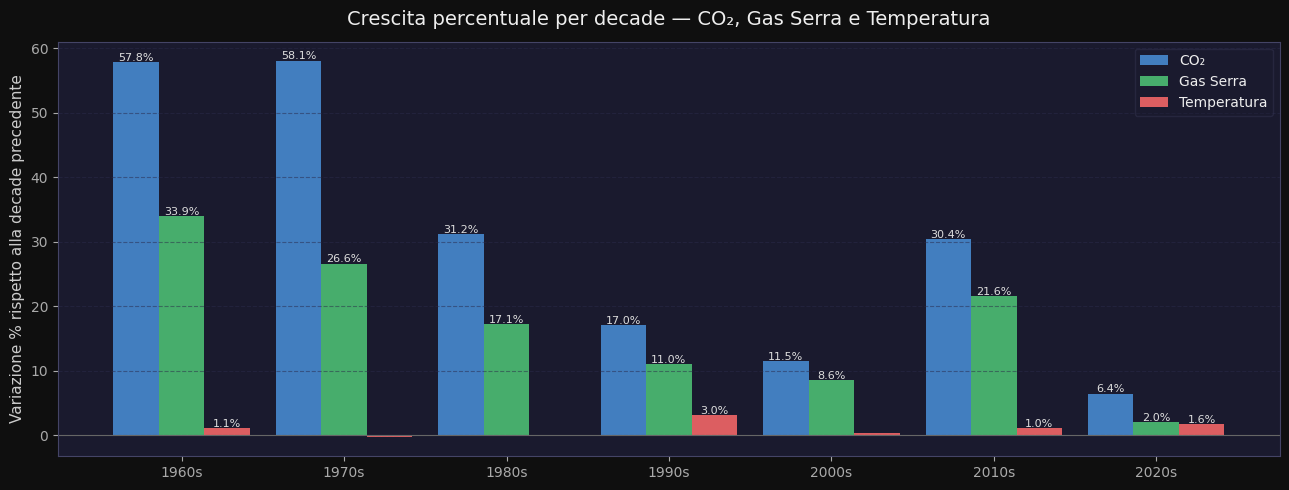

In [8]:
decades = list(range(1950, 2025, 10))
pct_co2  = global_co2.reindex(decades).pct_change()  * 100
pct_ghg  = global_ghg.reindex(decades).pct_change()  * 100
pct_temp = (global_temp.reindex(decades).diff()
            / global_temp.reindex(decades).shift() * 100)

labels = [f"{decades[i]}s" for i in range(1, len(decades))]
x = np.arange(len(labels))
w = 0.28

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w, pct_co2.dropna(),  w, label='CO₂',        color=PALETTE['co2'],  alpha=0.85)
b2 = ax.bar(x,     pct_ghg.dropna(),  w, label='Gas Serra',   color=PALETTE['ghg'],  alpha=0.85)
b3 = ax.bar(x + w, pct_temp.dropna(), w, label='Temperatura', color=PALETTE['temp'], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Variazione % rispetto alla decade precedente')
ax.set_title('Crescita percentuale per decade — CO₂, Gas Serra e Temperatura', pad=12)
ax.axhline(0, color='#666', linewidth=0.8)
ax.legend()
ax.grid(axis='y')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if abs(h) > 0.5:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + (0.2 if h >= 0 else -0.8),
                    f'{h:.1f}%', ha='center', fontsize=8, color='#ddd')

plt.tight_layout()
plt.show()

---
## 4. Analisi per fonte di emissione

Il carbone rimane la fonte dominante, ma il **gas naturale** è quella con la crescita più
rapida: +2.168% dal 1950 al 2024. L'aumento delle emissioni da cemento riflette la massiccia
urbanizzazione delle economie emergenti, in particolare Cina e India.

In [9]:
src = co2_c.groupby('year')[['coal_co2', 'oil_co2', 'gas_co2', 'cement_co2']].sum()
src.columns = ['Carbone', 'Petrolio', 'Gas', 'Cemento']

print("Variazioni assolute e percentuali per fonte (1950 → 2024):\n")
for col in src.columns:
    v0, v1 = src.loc[1950, col], src.loc[2024, col]
    print(f"  {col:<10}  {v0:>7,.0f} Mt  →  {v1:>7,.0f} Mt  ({(v1/v0-1)*100:>+8.1f}%)")

Variazioni assolute e percentuali per fonte (1950 → 2024):

  Carbone       3,855 Mt  →   15,802 Mt  (  +310.0%)
  Petrolio      1,439 Mt  →   11,268 Mt  (  +683.3%)
  Gas             353 Mt  →    8,009 Mt  ( +2167.9%)
  Cemento          67 Mt  →    1,473 Mt  ( +2101.5%)


In [10]:
fig = go.Figure()

colors_src = [PALETTE['coal'], PALETTE['oil'], PALETTE['gas'], PALETTE['cement']]

for col, color in zip(src.columns, colors_src):
    fig.add_trace(go.Scatter(
        x=src.index,
        y=src[col].round(1),
        name=col,
        mode='lines',
        line=dict(width=0.5, color=color),
        stackgroup='one',
        fillcolor=color,
        hovertemplate=f'<b>{col}</b>: %{{y:.0f}} MtCO₂<extra></extra>'
    ))

fig.update_layout(
    title='<b>Emissioni globali CO₂ per fonte — 1950–2024</b>',
    xaxis_title='Anno',
    yaxis_title='MtCO₂',
    height=450,
    paper_bgcolor='#0f0f0f',
    plot_bgcolor='#1a1a2e',
    font_color='#eeeeee',
    legend=dict(orientation='h', y=1.08),
    hovermode='x unified'
)
fig.update_xaxes(gridcolor='#2a2a4a')
fig.update_yaxes(gridcolor='#2a2a4a')
fig.show()

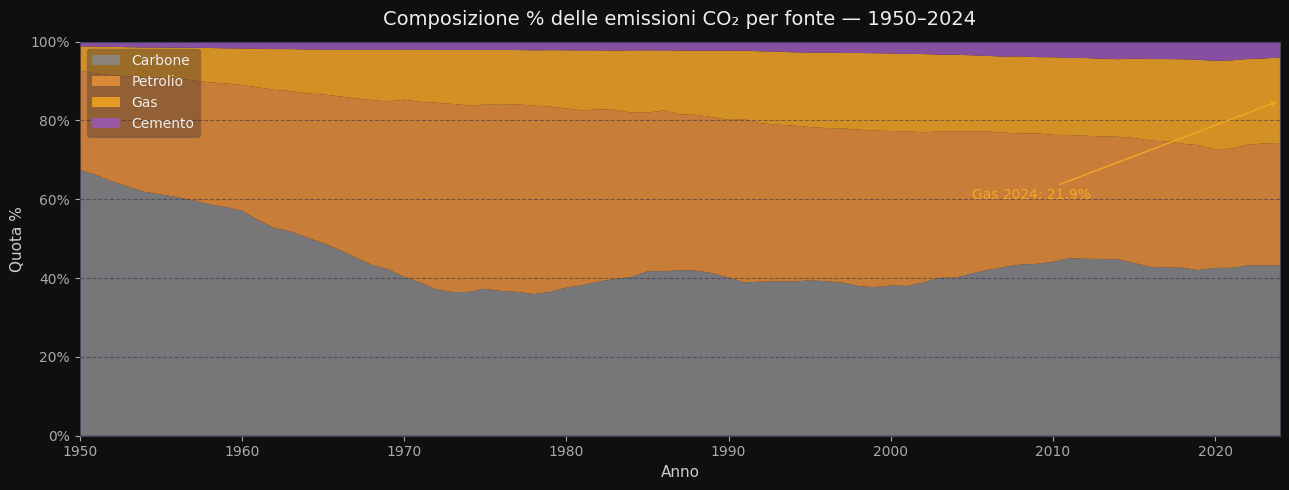

In [11]:
src_pct = src.div(src.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(
    src_pct.index,
    src_pct['Carbone'],
    src_pct['Petrolio'],
    src_pct['Gas'],
    src_pct['Cemento'],
    labels=src_pct.columns,
    colors=[PALETTE['coal'], PALETTE['oil'], PALETTE['gas'], PALETTE['cement']],
    alpha=0.85
)
ax.set_xlim(1950, 2024)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Anno')
ax.set_ylabel('Quota %')
ax.set_title('Composizione % delle emissioni CO₂ per fonte — 1950–2024', pad=12)
ax.legend(loc='upper left')
ax.grid(axis='y')

ax.annotate(f"Gas 2024: {src_pct.loc[2024,'Gas']:.1f}%",
            xy=(2024, src_pct.loc[2024,'Carbone'] + src_pct.loc[2024,'Petrolio']
                + src_pct.loc[2024,'Gas'] / 2),
            xytext=(2005, 60),
            arrowprops=dict(arrowstyle='->', color='#f5a623'),
            color='#f5a623', fontsize=10)

plt.tight_layout()
plt.show()

---
## 5. Top emettitori 2024

La Cina da sola produce il **32,9%** di tutta la CO₂ mondiale. Il dato pro capite ribalta
però la classifica: Arabia Saudita, Canada e Russia superano i 18–20 t/persona, mentre
India e Indonesia restano sotto le 3 t nonostante i volumi assoluti enormi.

In [12]:
top15_co2 = (co2_c[co2_c.year == 2024]
             .nlargest(15, 'co2')
             [['country', 'co2', 'co2_per_capita']]
             .reset_index(drop=True))

top15_ghg = (ghg_c[ghg_c.year == 2024]
             .nlargest(15, 'total_ghg')
             [['country', 'total_ghg', 'ghg_per_capita']]
             .reset_index(drop=True))

tot_co2 = global_co2[2024]
tot_ghg = global_ghg[2024]
top15_co2['quota_%'] = (top15_co2['co2'] / tot_co2 * 100).round(1)
top15_ghg['quota_%'] = (top15_ghg['total_ghg'] / tot_ghg * 100).round(1)

print("Top 15 emettitori CO₂ 2024:")
display(top15_co2.round(2))

Top 15 emettitori CO₂ 2024:


,country,co2,co2_per_capita,quota_%
0,China,12289.04,8.66,32.9
1,United States,4904.12,14.20,13.1
2,India,3193.48,2.20,8.5
3,Russia,1780.52,12.29,4.8
4,Japan,961.87,7.77,2.6
5,Indonesia,812.22,2.87,2.2
6,Iran,792.63,8.66,2.1
7,Saudi Arabia,692.13,20.38,1.9
8,South Korea,583.68,11.29,1.6
9,Germany,572.32,6.77,1.5


In [13]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Top 15 — CO₂ totale 2024 (MtCO₂)',
                                    'Top 15 — GHG totale 2024 (MtCO₂eq)'))

fig.add_trace(go.Bar(
    y=top15_co2.country[::-1],
    x=top15_co2.co2[::-1],
    orientation='h',
    marker_color=PALETTE['co2'],
    text=top15_co2['quota_%'][::-1].apply(lambda x: f'{x}%'),
    textposition='outside',
    name='CO₂'
), row=1, col=1)

fig.add_trace(go.Bar(
    y=top15_ghg.country[::-1],
    x=top15_ghg.total_ghg[::-1],
    orientation='h',
    marker_color=PALETTE['ghg'],
    text=top15_ghg['quota_%'][::-1].apply(lambda x: f'{x}%'),
    textposition='outside',
    name='GHG'
), row=1, col=2)

fig.update_layout(
    height=550,
    showlegend=False,
    title_text='<b>Principali emettitori globali 2024</b>',
    paper_bgcolor='#0f0f0f',
    plot_bgcolor='#1a1a2e',
    font_color='#eeeeee'
)
fig.update_xaxes(gridcolor='#2a2a4a', ticksuffix=' Mt')
fig.update_yaxes(gridcolor='#2a2a4a')
fig.show()

In [14]:
merged_2024 = (co2_c[co2_c.year == 2024][['country', 'iso_code', 'co2', 'co2_per_capita']]
               .merge(ghg_c[ghg_c.year == 2024][['iso_code', 'total_ghg']], on='iso_code')
               .dropna())

merged_2024 = merged_2024[merged_2024.co2 > 50]

fig = px.scatter(
    merged_2024,
    x='co2',
    y='co2_per_capita',
    size='total_ghg',
    color='co2_per_capita',
    hover_name='country',
    text='iso_code',
    color_continuous_scale='YlOrRd',
    size_max=60,
    labels={
        'co2':            'CO₂ totale (MtCO₂)',
        'co2_per_capita': 'CO₂ pro capite (t/persona)',
        'total_ghg':      'GHG totale (Mt)'
    },
    title='<b>CO₂ totale vs pro capite — dimensione bolla = GHG totale (2024)</b>'
)
fig.update_traces(textfont_size=8, textfont_color='white')
fig.update_layout(
    height=520,
    paper_bgcolor='#0f0f0f',
    plot_bgcolor='#1a1a2e',
    font_color='#eeeeee',
    coloraxis_colorbar=dict(title='tCO₂/cap')
)
fig.update_xaxes(type='log', title='CO₂ totale — scala logaritmica (MtCO₂)', gridcolor='#2a2a4a')
fig.update_yaxes(gridcolor='#2a2a4a')
fig.show()

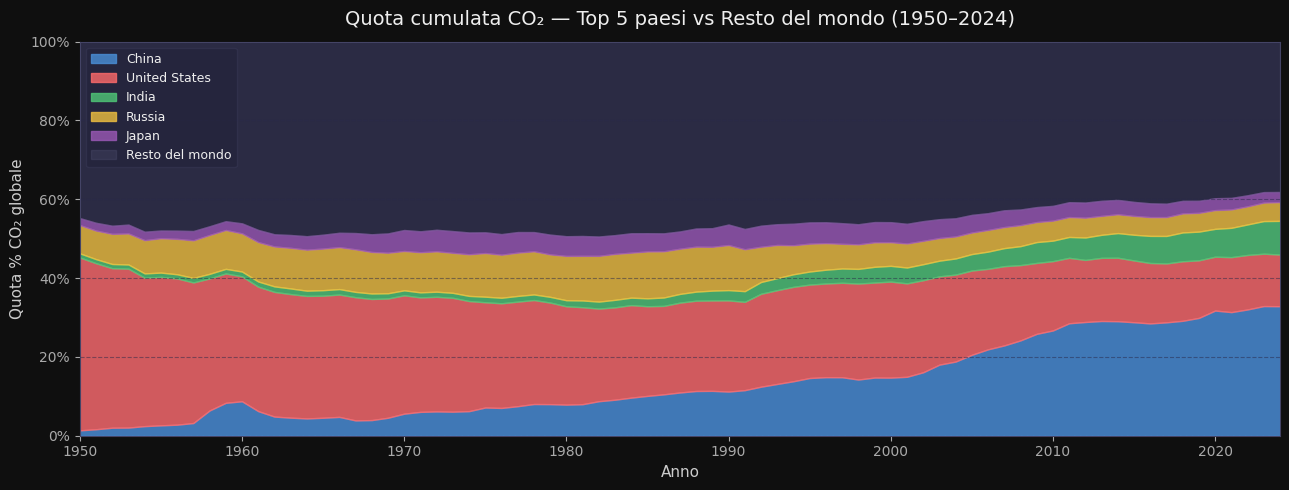

In [15]:
top5 = top15_co2.country[:5].tolist()
co2_yr_total = co2_c.groupby('year')['co2'].sum()

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(co2_yr_total))
colors_top5 = [PALETTE['co2'], PALETTE['temp'], PALETTE['ghg'],
               PALETTE['accent'], PALETTE['cement']]

for country, color in zip(top5, colors_top5):
    vals = (co2_c[co2_c.country == country]
            .set_index('year')['co2']
            .reindex(co2_yr_total.index, fill_value=0))
    pct = vals / co2_yr_total * 100
    ax.fill_between(co2_yr_total.index, bottom, bottom + pct.values,
                    alpha=0.8, label=country, color=color)
    bottom += pct.values

ax.fill_between(co2_yr_total.index, bottom, 100,
                alpha=0.3, label='Resto del mondo', color='#555577')

ax.set_xlim(1950, 2024)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Anno')
ax.set_ylabel('Quota % CO₂ globale')
ax.set_title('Quota cumulata CO₂ — Top 5 paesi vs Resto del mondo (1950–2024)', pad=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

---
## 6. Riscaldamento globale per paese

I paesi dell'Asia Centrale ex-sovietica registrano gli aumenti di temperatura più elevati
dal 1950. Uzbekistan (+3,48°C), Kazakhstan (+3,29°C) e Kyrgyzstan (+3,20°C) superano
abbondantemente il doppio della media globale di +1,65°C.

In [16]:
temp_pivot = temp_c.pivot_table(index='country', columns='year',
                                values='mean_temperature')
temp_pivot = temp_pivot.dropna(subset=[1950, 2024])
temp_pivot['delta'] = temp_pivot[2024] - temp_pivot[1950]
temp_pivot['iso_code'] = temp_c.groupby('country')['iso_code'].first()

top20_warm = temp_pivot['delta'].nlargest(20)
top10_cool = temp_pivot['delta'].nsmallest(10)

print(f"Media globale delta temperatura: +{temp_pivot['delta'].mean():.2f} °C")
print(f"Paese più riscaldato: {top20_warm.index[0]} ({top20_warm.iloc[0]:+.2f} °C)")
print(f"Paese meno riscaldato: {top10_cool.index[0]} ({top10_cool.iloc[0]:+.2f} °C)")

Media globale delta temperatura: +1.65 °C
Paese più riscaldato: Uzbekistan (+3.48 °C)
Paese meno riscaldato: Iceland (-0.09 °C)


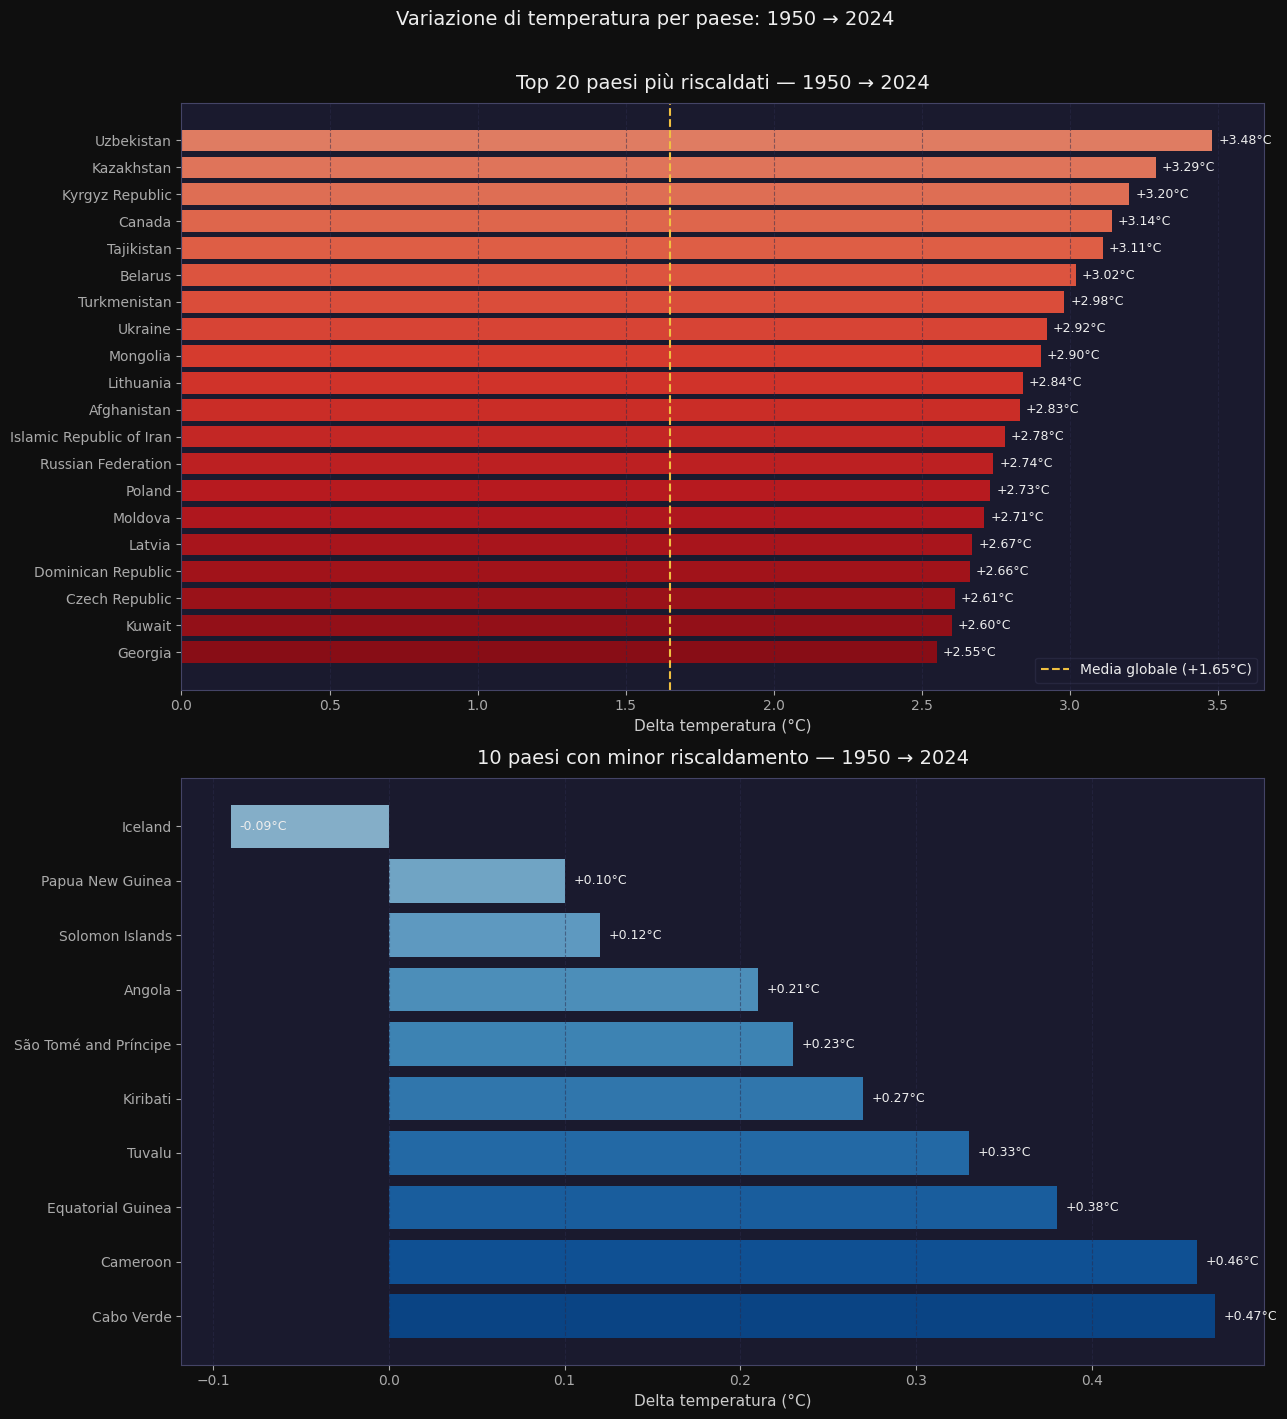

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(13, 14))

colors_warm = [plt.cm.Reds(0.4 + 0.5 * i / (len(top20_warm) - 1))
               for i in range(len(top20_warm))]

axes[0].barh(top20_warm.index[::-1], top20_warm.values[::-1],
             color=colors_warm[::-1], alpha=0.88)
axes[0].axvline(1.65, color=PALETTE['accent'], linestyle='--',
                linewidth=1.5, label='Media globale (+1.65°C)')
axes[0].set_xlabel('Delta temperatura (°C)')
axes[0].set_title('Top 20 paesi più riscaldati — 1950 → 2024', pad=10)
axes[0].legend(fontsize=10)
axes[0].grid(axis='x')
for i, (name, val) in enumerate(zip(top20_warm.index[::-1],
                                     top20_warm.values[::-1])):
    axes[0].text(val + 0.02, i, f'+{val:.2f}°C', va='center', fontsize=9)

colors_cool = [plt.cm.Blues(0.4 + 0.5 * i / (len(top10_cool) - 1))
               for i in range(len(top10_cool))]

axes[1].barh(top10_cool.index[::-1], top10_cool.values[::-1],
             color=colors_cool[::-1], alpha=0.88)
axes[1].set_xlabel('Delta temperatura (°C)')
axes[1].set_title('10 paesi con minor riscaldamento — 1950 → 2024', pad=10)
axes[1].grid(axis='x')
for i, (name, val) in enumerate(zip(top10_cool.index[::-1],
                                     top10_cool.values[::-1])):
    axes[1].text(val + 0.005, i, f'{val:+.2f}°C', va='center', fontsize=9)

plt.suptitle('Variazione di temperatura per paese: 1950 → 2024', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [18]:
countries_sel = {
    'Uzbekistan':         PALETTE['temp'],
    'Canada':             PALETTE['accent'],
    'Russian Federation': PALETTE['co2'],
    'Italy':              PALETTE['italy'],
    'India':              PALETTE['ghg'],
    'Brazil':             '#e05c9a',
    'Iceland':            '#aaaaaa',
}

fig = go.Figure()

for country, color in countries_sel.items():
    df_c = temp_c[temp_c.country == country].sort_values('year').set_index('year')
    if df_c.empty:
        continue
    smooth = df_c['mean_temperature'].rolling(5, center=True).mean()
    lw = 3 if country == 'Uzbekistan' else 1.8
    fig.add_trace(go.Scatter(
        x=smooth.index, y=smooth.round(2),
        name=country,
        mode='lines',
        line=dict(width=lw, color=color),
        hovertemplate=f'<b>{country}</b> %{{x}}: %{{y:.2f}}°C<extra></extra>'
    ))

fig.update_layout(
    title='<b>Temperatura media annuale — paesi selezionati (media mobile 5 anni)</b>',
    xaxis_title='Anno',
    yaxis_title='Temperatura (°C)',
    height=430,
    paper_bgcolor='#0f0f0f',
    plot_bgcolor='#1a1a2e',
    font_color='#eeeeee',
    legend=dict(orientation='h', y=1.08),
    hovermode='x unified'
)
fig.update_xaxes(gridcolor='#2a2a4a')
fig.update_yaxes(gridcolor='#2a2a4a')
fig.show()

---
## 7. Mappe coropletiche

Distribuzione geografica delle emissioni e del riscaldamento a livello mondiale.

In [19]:
df_map = (co2_c[co2_c.year == 2024]
          [['iso_code', 'country', 'co2', 'co2_per_capita']]
          .dropna())

fig = px.choropleth(
    df_map,
    locations='iso_code',
    color='co2_per_capita',
    hover_name='country',
    hover_data={'co2': ':.1f', 'co2_per_capita': ':.2f', 'iso_code': False},
    color_continuous_scale='YlOrRd',
    range_color=(0, 25),
    title='<b>CO₂ pro capite per paese — 2024 (tCO₂/persona)</b>',
    labels={'co2_per_capita': 'tCO₂/cap', 'co2': 'CO₂ tot. (Mt)'}
)
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='#444466',
        bgcolor='#0f0f0f',
        landcolor='#1a1a2e',
        lakecolor='#0f0f0f'
    ),
    paper_bgcolor='#0f0f0f',
    font_color='#eeeeee',
    coloraxis_colorbar=dict(title='tCO₂/cap'),
    height=460
)
fig.show()

In [20]:
delta_df = (temp_pivot[['delta', 'iso_code']]
            .reset_index())

fig = px.choropleth(
    delta_df.dropna(),
    locations='iso_code',
    color='delta',
    hover_name='country',
    color_continuous_scale='RdBu_r',
    color_continuous_midpoint=1.65,
    range_color=(0, 4),
    title='<b>Variazione temperatura per paese — 1950 → 2024 (°C)</b>',
    labels={'delta': 'Δ°C'}
)
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='#444466',
        bgcolor='#0f0f0f',
        landcolor='#2a2a3e'
    ),
    paper_bgcolor='#0f0f0f',
    font_color='#eeeeee',
    coloraxis_colorbar=dict(
        title='Δ°C',
        tickvals=[0, 1, 1.65, 2, 3, 4],
        ticktext=['0', '1', '1.65\n(media)', '2', '3', '4']
    ),
    height=460
)
fig.show()

In [21]:
years = list(range(1950, 2025, 5)) + [2024]

df_anim = (co2_c[co2_c.year.isin(years)]
           [['iso_code', 'country', 'year', 'co2_per_capita']]
           .dropna())

fig = px.choropleth(
    df_anim,
    locations='iso_code',
    color='co2_per_capita',
    hover_name='country',
    animation_frame='year',
    color_continuous_scale='YlOrRd',
    range_color=(0, 25),
    title='<b>Evoluzione CO₂ pro capite — 1950–2024 (ogni 5 anni)</b>',
    labels={'co2_per_capita': 'tCO₂/cap'}
)
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='#444466',
        bgcolor='#0f0f0f',
        landcolor='#1a1a2e'
    ),
    paper_bgcolor='#0f0f0f',
    font_color='#eeeeee',
    coloraxis_colorbar=dict(title='tCO₂/cap'),
    height=480,
    sliders=[dict(currentvalue=dict(prefix='Anno: ', font=dict(color='#eeeeee')))]
)
fig.show()

---
## 8. Correlazioni e insights statistici

La correlazione tra le emissioni globali di CO₂ e la temperatura media è molto elevata
(r = 0,895), pur non implicando causalità diretta in questo tipo di analisi descrittiva.

In [22]:
global_agg = pd.DataFrame({
    'co2':  global_co2,
    'ghg':  global_ghg,
    'temp': global_temp
}).dropna()

corr = global_agg.corr()
corr.index   = ['CO₂ globale', 'GHG globale', 'Temperatura']
corr.columns = ['CO₂ globale', 'GHG globale', 'Temperatura']

print("Matrice di correlazione (aggregati globali annuali):\n")
display(corr.round(4))

Matrice di correlazione (aggregati globali annuali):



,CO₂ globale,GHG globale,Temperatura
CO₂ globale,1.0000,0.9984,0.8946
GHG globale,0.9984,1.0000,0.8887
Temperatura,0.8946,0.8887,1.0000


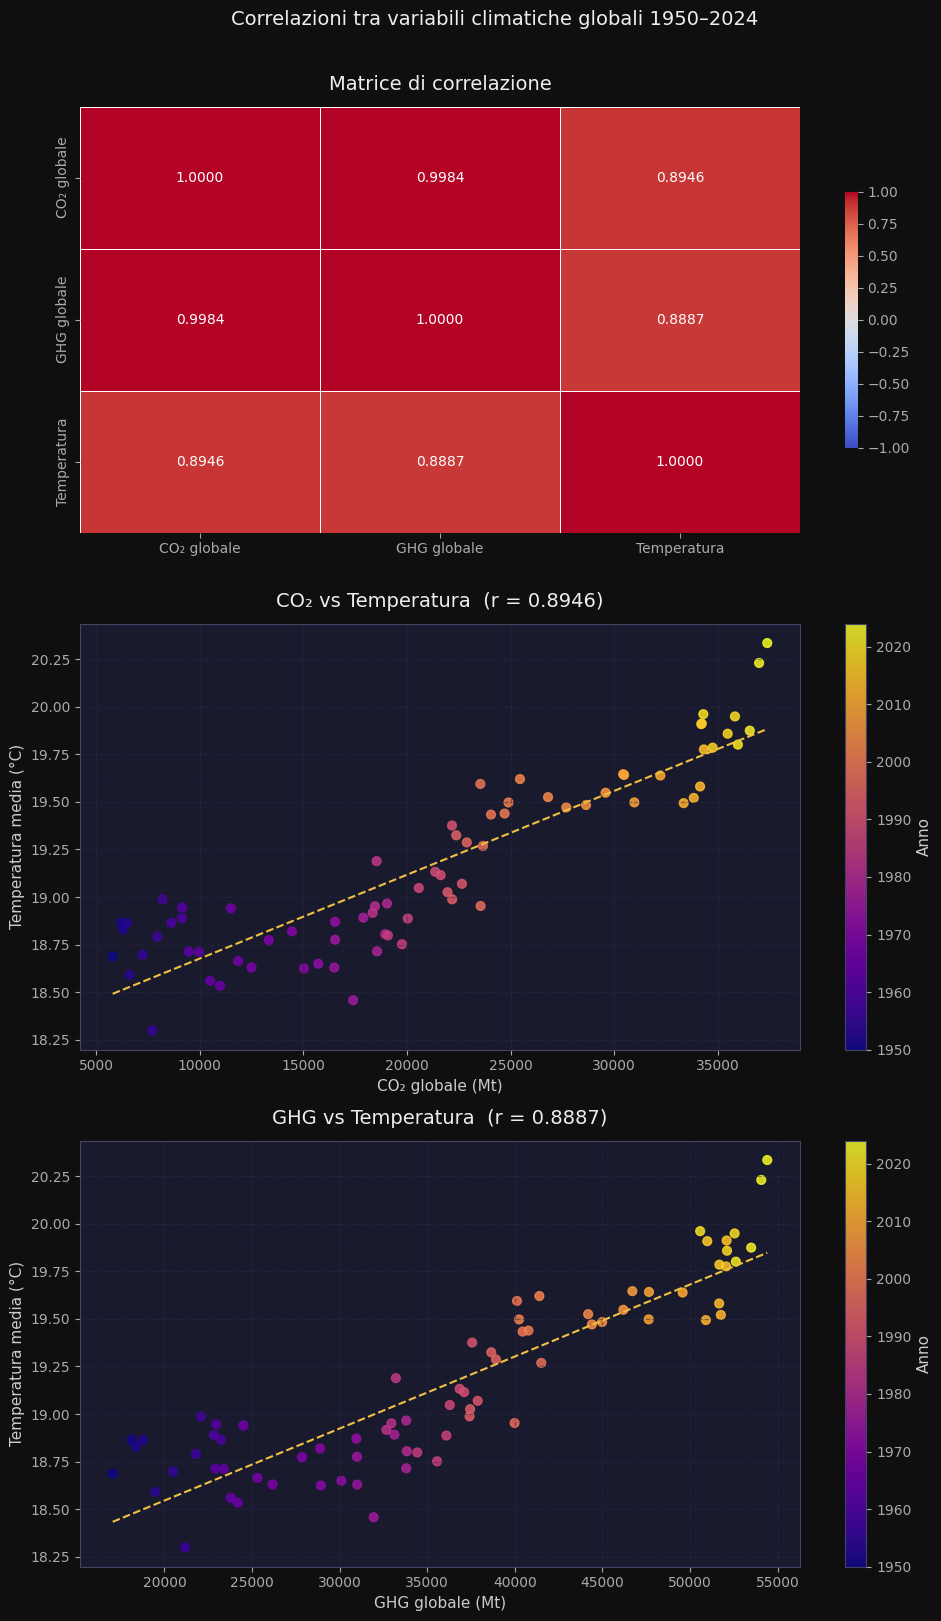

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(10, 16))

sns.heatmap(
    corr, annot=True, fmt='.4f',
    cmap='coolwarm', vmin=-1, vmax=1, center=0,
    linewidths=0.5, ax=axes[0],
    cbar_kws={'shrink': 0.6}
)
axes[0].set_title('Matrice di correlazione', pad=12)

sc1 = axes[1].scatter(
    global_agg['co2'], global_agg['temp'],
    c=global_agg.index, cmap='plasma', s=40, alpha=0.85
)
z = np.polyfit(global_agg['co2'], global_agg['temp'], 1)
p = np.poly1d(z)
axes[1].plot(sorted(global_agg['co2']), p(sorted(global_agg['co2'])),
             color=PALETTE['accent'], linestyle='--', linewidth=1.5)
axes[1].set_xlabel('CO₂ globale (Mt)')
axes[1].set_ylabel('Temperatura media (°C)')
axes[1].set_title('CO₂ vs Temperatura  (r = 0.8946)', pad=12)
axes[1].grid()
plt.colorbar(sc1, ax=axes[1], label='Anno')

sc2 = axes[2].scatter(
    global_agg['ghg'], global_agg['temp'],
    c=global_agg.index, cmap='plasma', s=40, alpha=0.85
)
z2 = np.polyfit(global_agg['ghg'], global_agg['temp'], 1)
p2 = np.poly1d(z2)
axes[2].plot(sorted(global_agg['ghg']), p2(sorted(global_agg['ghg'])),
             color=PALETTE['accent'], linestyle='--', linewidth=1.5)
axes[2].set_xlabel('GHG globale (Mt)')
axes[2].set_ylabel('Temperatura media (°C)')
axes[2].set_title('GHG vs Temperatura  (r = 0.8887)', pad=12)
axes[2].grid()
plt.colorbar(sc2, ax=axes[2], label='Anno')

plt.suptitle('Correlazioni tra variabili climatiche globali 1950–2024',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Conclusioni

Riepilogo dei principali risultati dell'analisi.

### Principali risultati

| Indicatore | 1950 | 2024 | Variazione |
|---|---|---|---|
| CO₂ globale | 5.792 MtCO₂ | 37.393 MtCO₂ | **+546%** |
| GHG globale | 17.040 MtCO₂eq | 54.412 MtCO₂eq | **+219%** |
| Temperatura media | 18,69°C | 20,34°C | **+1,65°C** |
| Primo emettitore CO₂ | USA | Cina | — |
| Fonte CO₂ più cresciuta | Carbone | Gas naturale | **+2.168%** |
| Paese più riscaldato | — | Uzbekistan | **+3,48°C** |

### Insights chiave

- **Cina** produce oggi il 32,9% della CO₂ mondiale, ma con un pro capite di soli 8,7 t/persona
- **Arabia Saudita** e **Kuwait** guidano la classifica pro capite con oltre 20–40 t/persona
- Il **Brasile** è 4° nei GHG ma non nei top 5 CO₂ — la deforestazione pesa enormemente
- I paesi dell'**Asia Centrale ex-sovietica** sono i più colpiti dal riscaldamento
- La correlazione CO₂/temperatura è **r = 0,895** sulla serie storica 1950–2024
- Il **gas naturale** è la fonte con la crescita più esplosiva: da 353 Mt a 8.009 Mt

### Limiti dell'analisi

- Le emissioni territoriali non includono i flussi commerciali internazionali
- La temperatura media nazionale semplifica la distribuzione spaziale intra-paese
- Le stime per gli anni più recenti (2023–2024) possono essere ancora provvisorie